aaaaaa考虑到样本直方图尾部的递减形状和正态分布有点像，以及正态分布的普遍性，我们再尝试用正态分布来拟合样本：


Executing Monte Carlo Simulation for Person3...


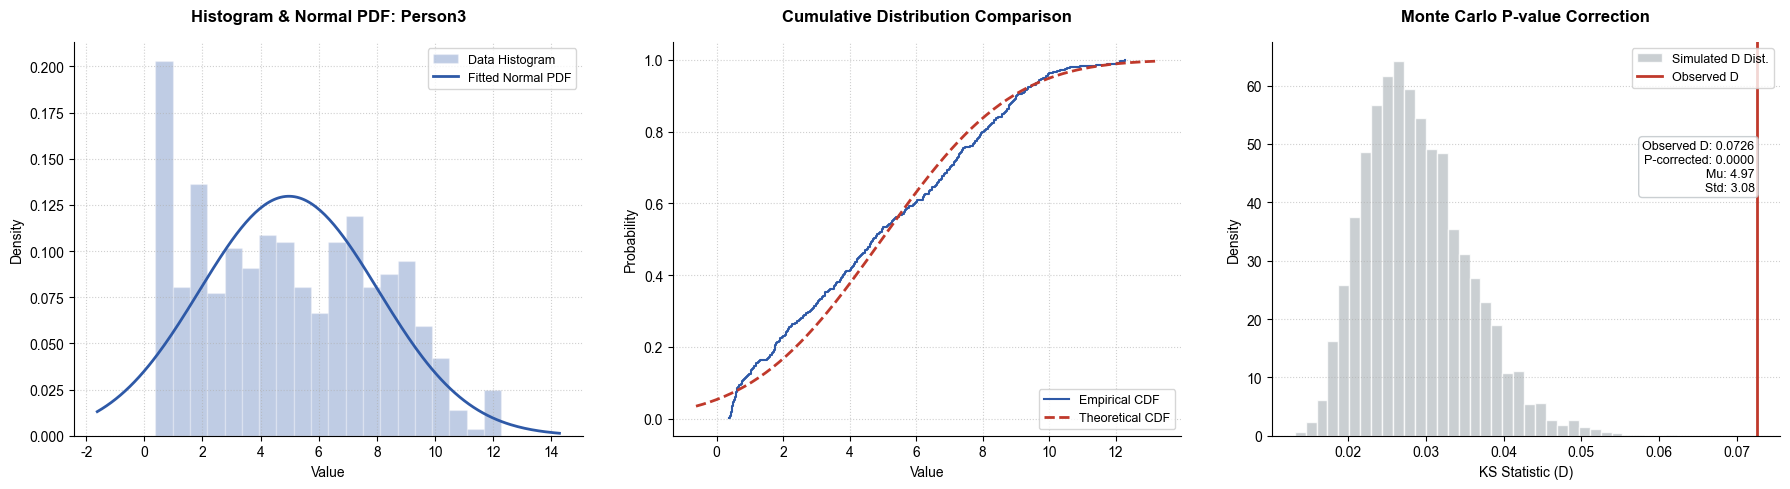

Results for Person3:
Normal Parameters: Mu=4.974, Std=3.077
KS Statistic D:    0.0726
Corrected P-value: 0.0000


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kstest
import io
df = pd.read_csv('envelopes.csv')
# 1. 数据准备
# 剔除最后一行 "Total"
df_clean = df[df['Trial'] != 'Total'].copy()

# 选择目标数据（这里以 Person1 为例）
target_person = 'Person3' 
data_values = df_clean[target_person].astype(float).values
n_samples = len(data_values)

# 2. 参数估计与 KS 统计量计算
mu_obs, std_obs = norm.fit(data_values)
d_obs, _ = kstest(data_values, 'norm', args=(mu_obs, std_obs))

# 3. 蒙特卡洛模拟 (5000次)
n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation for {target_person}...")
for i in range(n_sims):
    sim_sample = norm.rvs(loc=mu_obs, scale=std_obs, size=n_samples)
    mu_sim, std_sim = norm.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'norm', args=(mu_sim, std_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

# 4. 绘图 (调整为三子图，比例 18:5)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# 增加画布宽度以容纳三个图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# --- Plot 1: Histogram & PDF ---
# 绘制直方图 (使用较淡的蓝色)
ax1.hist(data_values, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
# 绘制 PDF 曲线 (使用深蓝色)
x_pdf = np.linspace(data_values.min() - 2, data_values.max() + 2, 200)
y_pdf = norm.pdf(x_pdf, mu_obs, std_obs)
ax1.plot(x_pdf, y_pdf, color='#2E59A7', lw=2, label='Fitted Normal PDF')

ax1.set_title(f'Histogram & Normal PDF: {target_person}', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: ECDF vs Normal CDF (配色保持一致) ---
sorted_data = np.sort(data_values)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_cdf = np.linspace(sorted_data.min() - 1, sorted_data.max() + 1, 200)
y_cdf = norm.cdf(x_cdf, loc=mu_obs, scale=std_obs)

ax2.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post')
ax2.plot(x_cdf, y_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2)

ax2.set_title('Cumulative Distribution Comparison', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Value', fontsize=10)
ax2.set_ylabel('Probability', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Plot 3: D-statistic Rank Analysis (配色保持一致) ---
ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax3.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label='Observed D')

ax3.set_title('Monte Carlo P-value Correction', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('KS Statistic (D)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6, axis='y')

# 标注信息框
text_str = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nMu: {mu_obs:.2f}\nStd: {std_obs:.2f}'
ax3.text(0.95, 0.75, text_str, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax3.legend(loc='upper right', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3.0)
plt.show()

# 控制台结果
print(f"Results for {target_person}:")
print(f"Normal Parameters: Mu={mu_obs:.3f}, Std={std_obs:.3f}")
print(f"KS Statistic D:    {d_obs:.4f}")
print(f"Corrected P-value: {p_corrected:.4f}")

但是正态分布模型的表现也不好